# Creating a PDK

A **Process Design Kit (PDK)** in kfactory is a `KCLayout` instance plus the layers,
enclosures, cross-sections, and factories that describe your process. Everything lives
in one place so every cell you create is consistent.

A minimal PDK has four ingredients:

| Ingredient | What it does |
|---|---|
| `KCLayout` | Root container for all cells, dbu setting, and registry objects |
| `LayerInfos` | Named layer definitions (`layer, datatype` pairs) |
| `LayerEnclosure` | Cladding/slab geometry rules around waveguide cores |
| Factories | Functions that stamp cells into the layout (straight, bend, taper, …) |

The section on [KCLayout](../concepts/kclayout.py) covers the layout object in depth.
The section on [Cross-Sections](../components/cross_sections.py) covers cross-section
registration. This page shows how to wire everything together into a single reusable
module.

## 1 · Layers

Define layers with `LayerInfos`. Each field is a `kdb.LayerInfo(layer, datatype)`.
Pass the **class** (not an instance) to `KCLayout` so the PDK can build its internal
layer index at construction time.

In [1]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)  # waveguide core
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)  # cladding oxide
    SLAB: kf.kdb.LayerInfo = kf.kdb.LayerInfo(3, 0)  # slab (rib process)
    METAL: kf.kdb.LayerInfo = kf.kdb.LayerInfo(20, 0)  # metal layer
    METALEX: kf.kdb.LayerInfo = kf.kdb.LayerInfo(20, 1)  # metal keep-out
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(99, 0)  # die outline

## 2 · Create a named `KCLayout`

`kf.kcl` is the default global layout. For a PDK you create a **named** layout so that
all your cells carry the PDK name and stay isolated from other layouts in the same
session.

Pass `infos=LAYER` (the class) so the PDK builds a `LayerEnum` from your layers. The
instantiated `LayerInfos` is then available as `pdk.infos`.

> **Tip:** Call `KCLayout` once at module level and import the resulting object
> everywhere in your PDK. Never recreate it — each `KCLayout` call registers a new
> entry in `kf.kcls`.

In [2]:
# Create the PDK layout with layers registered.
pdk = kf.KCLayout("MY_PDK", infos=LAYER)

# pdk.infos is the LayerInfos instance; use it for layer objects everywhere.
L = pdk.infos

print(f"PDK:  {pdk}")
print(f"dbu:  {pdk.dbu} µm/DBU  (1 nm grid)")
print(f"WG layer index: {pdk.find_layer(L.WG)}")

PDK:  name='MY_PDK' layout=<klayout.dbcore.Layout object at 0x7f2ce504c830> layer_enclosures=LayerEnclosureModel(root={}) cross_sections={} enclosure=KCellEnclosure(enclosures=LayerEnclosureCollection(enclosures=[])) library=<klayout.dbcore.Library object at 0x7f2ce514ab70> factories=<kfactory.layout.Factories object at 0x7f2ce53e34d0> virtual_factories=<kfactory.layout.Factories object at 0x7f2ce5210fc0> tkcells={} layers=<aenum 'LAYER'> infos=LAYER(WG=WG (1/0), WGCLAD=WGCLAD (2/0), SLAB=SLAB (3/0), METAL=METAL (20/0), METALEX=METALEX (20/1), FLOORPLAN=FLOORPLAN (99/0)) layer_stack=LayerStack(layers={}) netlist_layer_mapping={} sparameters_path=None interconnect_cml_path=None constants=Constants() rename_function=<function rename_clockwise_multi at 0x7f2d0e34a350> thread_lock=<unlocked _thread.RLock object owner=0 count=0 at 0x7f2d00f1def0> info=Info() settings=KCellSettings(version='3.0.0rc1', klayout_version='0.30.8', meta_format='v3') future_cell_name=None decorators=<kfactory.deco

## 3 · Enclosures

A `LayerEnclosure` describes the cladding/slab geometry added around waveguide cores.
Register it with the layout so routers and cross-sections can look it up by name.

The `sections` list uses `(layer, d_max)` for symmetric growth or
`(layer, d_min, d_max)` for annular (ring) regions. Values are in **DBU**.

In [3]:
# Standard strip waveguide enclosure: 2 µm oxide cladding.
enc_strip = pdk.get_enclosure(
    kf.LayerEnclosure(
        name="STRIP",
        main_layer=L.WG,
        sections=[
            (L.WGCLAD, 0, 2_000),  # 0–2 µm cladding
        ],
    )
)

# Rib waveguide: cladding + partial slab.
enc_rib = pdk.get_enclosure(
    kf.LayerEnclosure(
        name="RIB",
        main_layer=L.WG,
        sections=[
            (L.WGCLAD, 0, 2_000),  # 0–2 µm cladding
            (L.SLAB, 0, 4_000),  # 0–4 µm slab
        ],
    )
)

print(f"strip enclosure: {enc_strip.name}")
print(f"rib   enclosure: {enc_rib.name}")

strip enclosure: STRIP
rib   enclosure: RIB


## 4 · Cross-sections

A cross-section pairs an enclosure with a core width and bend-radius hints.
`DCrossSection` accepts µm; it converts to DBU when registered in the layout.

Cross-sections are stored in `pdk.cross_sections` keyed by name.  You retrieve
them later with `pdk.get_icross_section("WG_500")` (DBU view) or
`pdk.get_dcross_section("WG_500")` (µm view).

In [4]:
# Strip waveguide — 500 nm core, 2 µm cladding, 10 µm nominal bend radius.
xs_strip = kf.DCrossSection(
    kcl=pdk,
    width=0.5,  # µm
    layer=L.WG,
    sections=[
        (L.WGCLAD, 2.0),  # cladding: 0 → 2 µm
    ],
    radius=10.0,  # preferred bend radius (µm) — routing hint
    radius_min=5.0,  # minimum bend radius (µm) — DRC hint
    name="WG_500",
)

# Register and obtain the DBU-unit view.
xs_strip_dbu = pdk.get_icross_section(xs_strip)
print(f"cross-section:  {xs_strip_dbu.name}")
print(f"core width DBU: {xs_strip_dbu.width}  ({pdk.to_um(xs_strip_dbu.width):.3f} µm)")
print(f"radius (µm):    {pdk.to_um(xs_strip_dbu.radius):.1f}")

cross-section:  WG_500
core width DBU: 500  (0.500 µm)
radius (µm):    10.0


In [5]:
# Rib waveguide — 700 nm core, cladding + slab, 15 µm radius.
xs_rib = kf.DCrossSection(
    kcl=pdk,
    width=0.7,
    layer=L.WG,
    sections=[
        (L.WGCLAD, 2.0),
        (L.SLAB, 4.0),
    ],
    radius=15.0,
    radius_min=8.0,
    name="WG_700_RIB",
)
pdk.get_icross_section(xs_rib)

print(f"registered cross-sections: {list(pdk.cross_sections.cross_sections)}")

registered cross-sections: ['WG_500', 'WG_700_RIB']


## 5 · Factories

A **factory** is a function that creates cells bound to a specific `KCLayout`.
Call the factory once with `kcl=pdk` to get a cell-creation function.
That function is then called with the per-instance parameters.

| Factory | Module | Width/length units |
|---|---|---|
| `straight_dbu_factory` | `kf.factories.straight` | **DBU** |
| `bend_euler_factory` | `kf.factories.euler` | **µm** |
| `bend_circular_factory` | `kf.factories.circular` | **µm** |
| `taper_factory` | `kf.factories.taper` | **DBU** |

> **Why two unit systems?** Straight waveguides need exact DBU lengths for DRC-clean
> port placement; bend radii are naturally specified in µm by process specs.

In [6]:
# ── Straight waveguide factory (widths/lengths in DBU) ────────────────────
straight = kf.factories.straight.straight_dbu_factory(kcl=pdk)

# ── Euler bend factory (width and radius in µm) ───────────────────────────
bend_euler = kf.factories.euler.bend_euler_factory(kcl=pdk)

# ── 90° S-bend factory ────────────────────────────────────────────────────
bend_s = kf.factories.euler.bend_s_euler_factory(kcl=pdk)

# ── Taper factory (widths/length in DBU) ─────────────────────────────────
taper = kf.factories.taper.taper_factory(kcl=pdk)

### Stamping cells

Call each factory with the desired parameters.  The `@cell` decorator inside every
factory caches the result — calling with the same parameters returns the same object.

In [7]:
wg = straight(
    width=pdk.to_dbu(0.5),  # 500 nm → DBU
    length=pdk.to_dbu(20.0),  # 20 µm → DBU
    layer=L.WG,
    enclosure=enc_strip,
)

bend = bend_euler(
    width=0.5,  # µm
    radius=10.0,  # µm
    layer=L.WG,
    enclosure=enc_strip,
    angle=90,
)

tp = taper(
    width1=pdk.to_dbu(0.5),  # narrow end
    width2=pdk.to_dbu(1.0),  # wide end
    length=pdk.to_dbu(10.0),
    layer=L.WG,
    enclosure=enc_strip,
)

print(f"straight:  {wg}")
print(f"bend90:    {bend}")
print(f"taper:     {tp}")

straight:  KCell(name=straight_W500_L20000_LWG_ESTRIP, ports=['o1', 'o2'], pins=[], instances=[], locked=True, kcl=MY_PDK)
bend90:    KCell(name=bend_euler_W0p5_R10_LWG_ESTRIP_A90_R150, ports=['o1', 'o2'], pins=[], instances=[], locked=True, kcl=MY_PDK)
taper:     KCell(name=taper_W500_W1000_L10000_LWG_ESTRIP, ports=['o1', 'o2'], pins=[], instances=[], locked=True, kcl=MY_PDK)


## 6 · Custom cells using PDK factories

Build compound cells by combining the primitives.  The `@pdk.cell` decorator caches
the result and enforces port naming.

> **Important:** always pass `kcl=pdk` when constructing `kf.Port` objects inside a
> custom PDK cell. Without it kfactory defaults to the global `kf.kcl` layout, which
> makes layer indices inconsistent.

mmi_1x2 ports: ['o1', 'o2', 'o3']


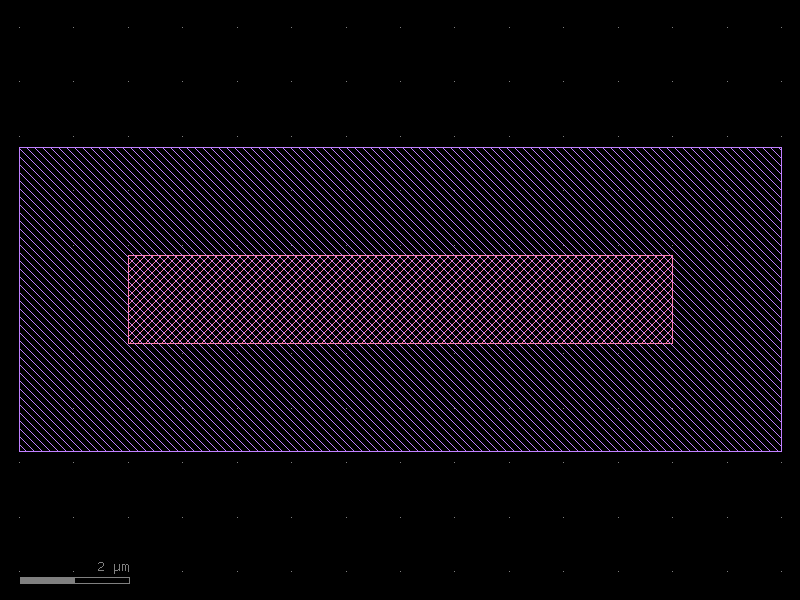

In [8]:
@pdk.cell
def mmi_1x2(
    width: float = 0.5,  # µm — waveguide core width
    gap: float = 0.2,  # µm — gap between output waveguides
    length: float = 10.0,  # µm — MMI body length
) -> kf.KCell:
    """1×2 multimode-interference splitter.

    Args:
        width: Waveguide core width (µm).
        gap: Gap between the two output waveguides (µm).
        length: MMI body length (µm).
    """
    c = pdk.kcell()

    # Convert µm to DBU for shape/port placement.
    width_dbu = pdk.to_dbu(width)
    gap_dbu = pdk.to_dbu(gap)
    length_dbu = pdk.to_dbu(length)

    # MMI body: wide enough for two waveguides + gap + margin.
    body_width_dbu = 2 * width_dbu + gap_dbu + pdk.to_dbu(0.4)

    # Core rectangle.
    wg_li = pdk.find_layer(L.WG)
    c.shapes(wg_li).insert(
        kf.kdb.Box(
            -length_dbu // 2,
            -body_width_dbu // 2,
            length_dbu // 2,
            body_width_dbu // 2,
        )
    )
    # Cladding rectangle.
    clad_margin = pdk.to_dbu(2.0)
    c.shapes(pdk.find_layer(L.WGCLAD)).insert(
        kf.kdb.Box(
            -length_dbu // 2 - clad_margin,
            -body_width_dbu // 2 - clad_margin,
            length_dbu // 2 + clad_margin,
            body_width_dbu // 2 + clad_margin,
        )
    )

    # Input port (West face).  Always pass kcl=pdk so the port layer index
    # is resolved in the correct layout.
    c.add_port(
        port=kf.Port(
            name="o1",
            trans=kf.kdb.Trans(2, False, -length_dbu // 2, 0),
            width=width_dbu,
            layer=wg_li,
            port_type="optical",
            kcl=pdk,  # required when using a custom KCLayout
        )
    )

    # Two output ports (East face), vertically offset by ±(width+gap)/2.
    y_out = (width_dbu + gap_dbu) // 2
    for name, y in [("o2", y_out), ("o3", -y_out)]:
        c.add_port(
            port=kf.Port(
                name=name,
                trans=kf.kdb.Trans(0, False, length_dbu // 2, y),
                width=width_dbu,
                layer=wg_li,
                port_type="optical",
                kcl=pdk,
            )
        )

    return c


splitter = mmi_1x2()
print(f"mmi_1x2 ports: {[p.name for p in splitter.ports]}")
splitter.plot()

## 7 · Assembling a circuit

Use `<<` to place cells (returns an `Instance`) and `connect()` to snap ports together.
The following builds a simple Y-splitter + arms circuit to show the assembly pattern.

splitter_arms ports: ['o1', 'o2', 'o3']


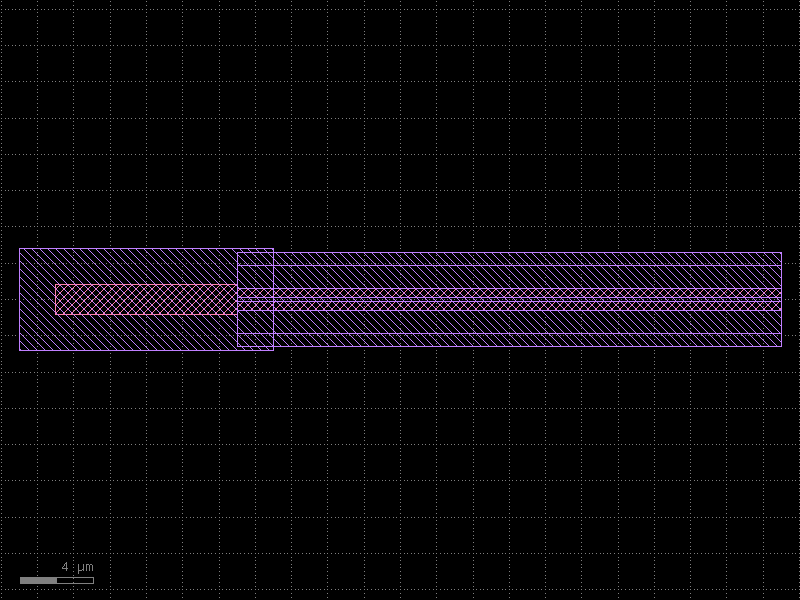

In [9]:
@pdk.cell
def splitter_arms(arm_length: float = 50.0) -> kf.KCell:
    """Y-splitter followed by two straight waveguide arms.

    Args:
        arm_length: Length of each output arm (µm).
    """
    c = pdk.kcell()

    # Place splitter at the origin.
    sp = c << mmi_1x2()

    # Straight arm cell — length is the same for both arms.
    arm_wg = straight(
        width=pdk.to_dbu(0.5),
        length=pdk.to_dbu(arm_length),
        layer=L.WG,
        enclosure=enc_strip,
    )

    top_arm = c << arm_wg
    bot_arm = c << arm_wg

    # Snap arm inputs to the splitter outputs.
    top_arm.connect("o1", sp, "o2")
    bot_arm.connect("o1", sp, "o3")

    # Expose the circuit ports (pass name= to rename on the parent).
    c.add_port(port=sp.ports["o1"], name="o1")
    c.add_port(port=top_arm.ports["o2"], name="o2")
    c.add_port(port=bot_arm.ports["o2"], name="o3")

    return c


fork = splitter_arms(arm_length=30.0)
print(f"splitter_arms ports: {[p.name for p in fork.ports]}")
fork.plot()

## 8 · PDK module pattern

In a real project you package the code above as a Python module, for example
`my_pdk/__init__.py`. Other design files then do:

```python
from my_pdk import pdk, L, straight, bend_euler, taper, mmi_1x2

c = pdk.kcell()
wg = straight(width=pdk.to_dbu(0.5), length=pdk.to_dbu(20), layer=L.WG)
...
```

The recommended structure is:

```
my_pdk/
  __init__.py        — re-exports pdk, L, factories, cells
  layers.py          — LAYER(LayerInfos) class
  enclosures.py      — enc_strip, enc_rib, …
  cross_sections.py  — xs_strip, xs_rib, …
  cells/
    __init__.py
    mmi.py           — mmi_1x2, mmi_2x2, …
    ring.py          — ring_resonator, …
  factories.py       — straight, bend_euler, taper, …
```

All modules import `pdk` from the top-level `__init__.py` so they share one
`KCLayout` object.

> **Note:** the `KCLayout` constructor takes `infos=LAYER` (the **class**), not an
> instance. The resulting `LayerInfos` instance is available as `pdk.infos`.

## 9 · GDS export

When the design is complete, write the whole layout to a GDS file.
All cells registered in `pdk` (including sub-cells) are written in one call.

In [10]:
import pathlib
import tempfile

with tempfile.TemporaryDirectory() as tmp:
    gds_path = pathlib.Path(tmp) / "my_pdk.gds"
    pdk.write(str(gds_path))
    size = gds_path.stat().st_size
    print(f"Written: {gds_path.name}  ({size} bytes)")
    print(f"Top cells: {[c.name for c in pdk.top_kcells()]}")

Written: my_pdk.gds  (12288 bytes)
Top cells: ['straight_W500_L20000_LWG_ESTRIP', 'bend_euler_W0p5_R10_LWG_ESTRIP_A90_R150', 'taper_W500_W1000_L10000_LWG_ESTRIP', 'splitter_arms_AL30']


## See Also

| Topic | Where |
|-------|-------|
| Layer stacks & technology data | [PDK: Technology](technology.py) |
| Cross-sections (port geometry) | [Cross-Sections](../components/cross_sections.py) |
| Layer enclosures (auto-cladding) | [Enclosures: Layer Enclosure](../enclosures/layer_enclosure.py) |
| PCells & caching | [Components: PCells](../components/cells/pcells.py) |
| Factory functions reference | [Components: Factories](../components/cells/factories/overview.py) |
| Session caching (fast reload) | [Utilities: Session Cache](../utilities/session_cache.py) |